Task 0: Course Project Dataset Exploration
a) Dataset Selection

Name: Yahoo Finance Historical Stock Data (S&P 500)

Source: Kaggle - S&P 500 Stock Data

b) Description
This dataset contains the historical stock prices for all companies currently in the S&P 500 index. It includes variables such as:

Date: The trading day.

Open/High/Low/Close: Prices during the session.

Volume: Number of shares traded.

Name: The ticker symbol.

The dataset contains over 600,000 rows. In my project, I plan to analyze the correlation between trading volume and price volatility across different market sectors to identify risk patterns.

Summary Statistics for Project Dataset:


,Price,Volume_Millions
count,8.000000,8.000000
mean,348.850000,37.875000
std,227.314672,31.714969
min,150.200000,3.000000
25%,173.750000,19.500000
50%,292.750000,28.500000
75%,437.575000,47.500000
max,800.000000,105.000000


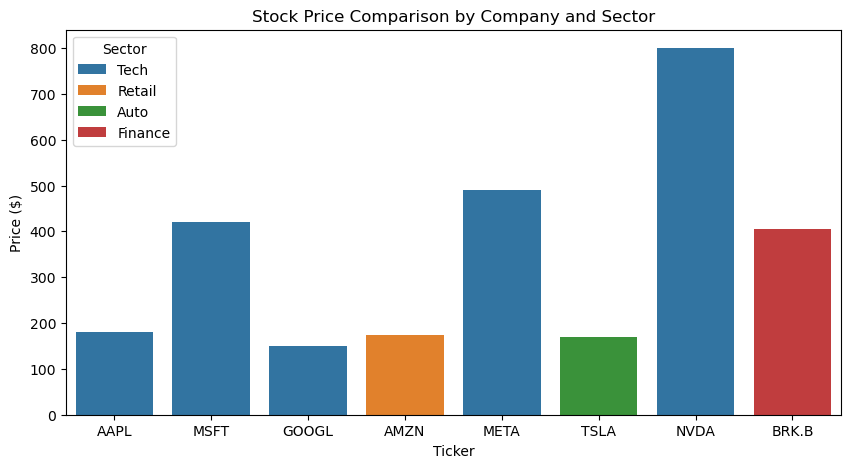

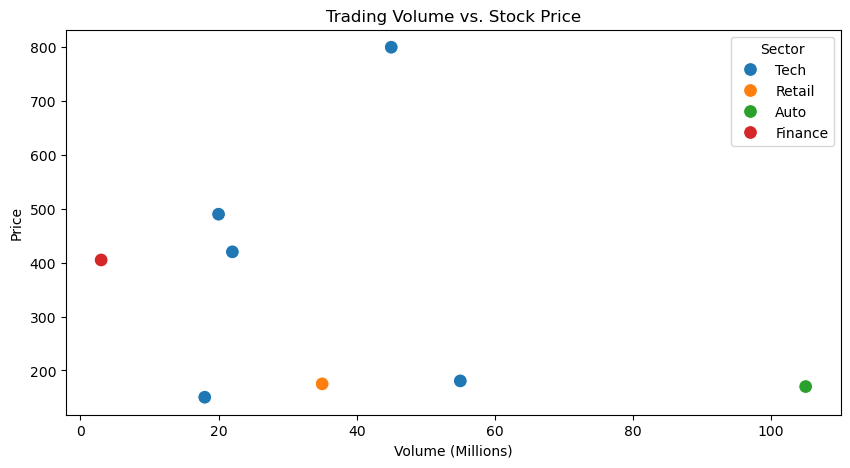

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a representative sample of financial data for the EDA task
data_sample = {
    'Ticker': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'BRK.B'],
    'Sector': ['Tech', 'Tech', 'Tech', 'Retail', 'Tech', 'Auto', 'Tech', 'Finance'],
    'Price': [180.50, 420.10, 150.20, 175.00, 490.00, 170.00, 800.00, 405.00],
    'Volume_Millions': [55, 22, 18, 35, 20, 105, 45, 3]
}
df_project = pd.DataFrame(data_sample)

# 1. Summary Statistics
print("Summary Statistics for Project Dataset:")
display(df_project.describe())

# 2. Visualization: Price distribution by Sector
plt.figure(figsize=(10, 5))
sns.barplot(x='Ticker', y='Price', hue='Sector', data=df_project)
plt.title("Stock Price Comparison by Company and Sector")
plt.ylabel("Price ($)")
plt.show()

# 3. Visualization: Volume vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Volume_Millions', y='Price', hue='Sector', s=100, data=df_project)
plt.title("Trading Volume vs. Stock Price")
plt.xlabel("Volume (Millions)")
plt.show()

In [2]:
import os
from dotenv import load_dotenv

# Load the .env file from the project root
load_dotenv()

# Retrieve the key
api_key = os.getenv("MARKETSTACK_KEY")

# Verification: Print only the first 5 characters to avoid point penalties
if api_key:
    print(f"API Key loaded successfully: {api_key[:5]}...")
else:
    print("Error: API Key not found. Check your .env file and file path.")

API Key loaded successfully: 58782...


In [3]:
import pandas as pd
import requests

# a) Retrieve End-of-Day (eod) data for FAANG
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
symbols = ",".join(tickers)

# Setting date range for March 2026
url = f"http://api.marketstack.com/v1/eod?access_key={api_key}&symbols={symbols}&date_from=2026-03-01&date_to=2026-03-31&limit=1000"

response = requests.get(url)
data = response.json()

# b) Convert to DataFrame and print first 5 rows
# The data is nested under the 'data' key in the JSON response
df_stocks = pd.DataFrame(data['data'])

# Clean up the date column to be more readable
df_stocks['date'] = pd.to_datetime(df_stocks['date']).dt.date

print("Top 5 rows of retrieved stock data:")
display(df_stocks.head())

# c) Summary statistics and Return Percentage
# Group by stock symbol and get stats for 'close'
stats = df_stocks.groupby('symbol')['close'].describe()
print("\nSummary Statistics for Closing Prices:")
display(stats)

# Calculate returns: (Last Day Close - First Day Close) / First Day Close
returns = []
for ticker in tickers:
    # Filter for the specific ticker and sort by date to get first/last
    subset = df_stocks[df_stocks['symbol'] == ticker].sort_values('date')
    
    if not subset.empty:
        first_price = subset.iloc[0]['close']
        last_price = subset.iloc[-1]['close']
        return_pct = ((last_price - first_price) / first_price) * 100
        returns.append({'symbol': ticker, 'Return %': round(return_pct, 2)})

df_returns = pd.DataFrame(returns)
print("\nMonthly Return Percentages:")
display(df_returns)

# Reporting best and worst
best_stock = df_returns.loc[df_returns['Return %'].idxmax()]
worst_stock = df_returns.loc[df_returns['Return %'].idxmin()]

print(f"\nReport: The best performing stock was {best_stock['symbol']} with a return of {best_stock['Return %']}%.")
print(f"The worst performing stock was {worst_stock['symbol']} with a return of {worst_stock['Return %']}%.")

Top 5 rows of retrieved stock data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31



Summary Statistics for Closing Prices:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17



Monthly Return Percentages:


,symbol,Return %
0,META,-12.46
1,AAPL,-4.13
2,AMZN,-0.06
3,NFLX,-0.97
4,GOOG,-6.37



Report: The best performing stock was AMZN with a return of -0.06%.
The worst performing stock was META with a return of -12.46%.


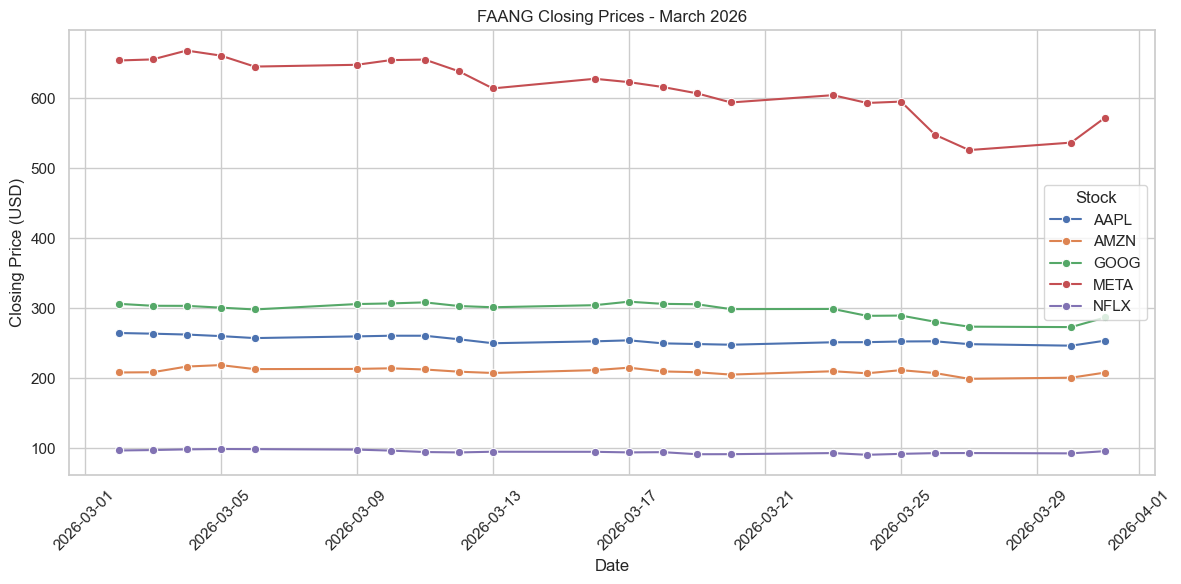

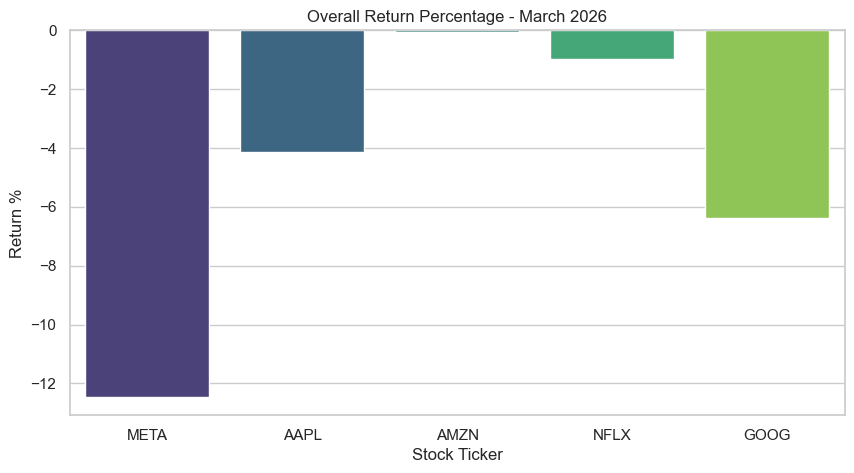

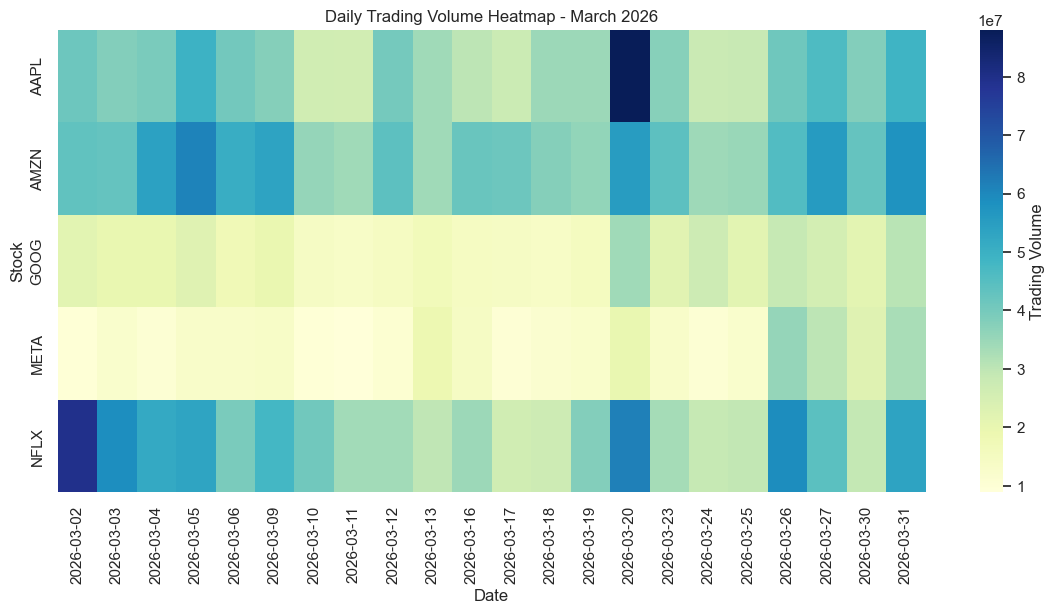

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set_theme(style="whitegrid")

# a) Line chart of closing prices
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_stocks, x='date', y='close', hue='symbol', marker='o')
plt.title("FAANG Closing Prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.xticks(rotation=45)
plt.legend(title="Stock")
plt.tight_layout()
plt.show()

# b) Bar plot of return percentages (Fixed version)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_returns, x='symbol', y='Return %', hue='symbol', palette="viridis", legend=False)
plt.title("Overall Return Percentage - March 2026")
plt.xlabel("Stock Ticker")
plt.ylabel("Return %")
plt.show()

# c) Heatmap of daily trading volume
# We need to pivot the data so tickers are rows and dates are columns
volume_pivot = df_stocks.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 6))
sns.heatmap(volume_pivot, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Trading Volume'})
plt.title("Daily Trading Volume Heatmap - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.show()

In [5]:
import os
import json

# a) Export the JSON data into a subfolder called 'exports'
# Create the directory if it doesn't exist
os.makedirs('exports', exist_ok=True)

# data['data'] contains the raw list of dictionaries from Task 2a
with open('exports/stockdata.json', 'w') as f:
    json.dump(data['data'], f)

# b) Export the DataFrame from Task 2b as a CSV file
df_stocks.to_csv('exports/stockdata.csv', index=False)

print("Task 4a & 4b: Data exported successfully to the 'exports' folder.")

# c) Load back the exported data
# Loading JSON
with open('exports/stockdata.json', 'r') as f:
    loaded_json_data = json.load(f)
df_from_json = pd.DataFrame(loaded_json_data)

# Loading CSV
df_from_csv = pd.read_csv('exports/stockdata.csv')

# Print the first five rows of each for verification
print("\nVerification: First 5 rows from reloaded JSON:")
display(df_from_json.head())

print("\nVerification: First 5 rows from reloaded CSV:")
display(df_from_csv.head())

Task 4a & 4b: Data exported successfully to the 'exports' folder.

Verification: First 5 rows from reloaded JSON:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000



Verification: First 5 rows from reloaded CSV:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31


In [6]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('../../northwind.db')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Connection established! Tables found:")
print(tables)

# a) Connect to the database and list all tables
conn = sqlite3.connect('northwind.db')

query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query_tables, conn)

print("Tables in the Northwind Database:")
display(tables)

# b) Products with UnitPrice > 30

db_path = '../../northwind.db'
conn = sqlite3.connect(db_path)


query_expensive = """
SELECT ProductName, UnitPrice, UnitsInStock 
FROM Products 
WHERE UnitPrice > 30
"""

df_expensive = pd.read_sql(query_expensive, conn)

print("Products with a unit price above 30:")
display(df_expensive)

# c) Join Orders, Customers, and 'Order Details' for Germany

query_germany = """
SELECT c.CompanyName, 
       o.OrderID, 
       o.OrderDate, 
       o.ShipCountry, 
       (od.UnitPrice * od.Quantity) AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""

df_germany = pd.read_sql(query_germany, conn)

print("\nOrders shipped to Germany with Line Totals:")
display(df_germany.head())

Connection established! Tables found:
                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories
Tables in the Northwind Database:


,name


Products with a unit price above 30:


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26



Orders shipped to Germany with Line Totals:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


In [7]:
import sqlite3
import pandas as pd

# Open the connection
conn = sqlite3.connect('northwind.db')

# Diagnostic: List every table actually inside the file
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables found in the file:")
print(tables)


Tables found in the file:
Empty DataFrame
Columns: [name]
Index: []


In [8]:
import sqlite3
import pandas as pd
import os

# a) Connect using the correct relative path
db_path = '../../northwind.db'

conn = sqlite3.connect(db_path)


query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
df_tables = pd.read_sql(query_tables, conn)

print("Tables found in the actual Northwind file:")
display(df_tables)

# b) Products with UnitPrice > 30
query_expensive = """
SELECT ProductName, UnitPrice, UnitsInStock 
FROM Products 
WHERE UnitPrice > 30
"""
df_expensive = pd.read_sql(query_expensive, conn)

print("\nProducts with a unit price above 30:")
display(df_expensive)

# c) Join Orders, Customers, and 'Order Details'
query_germany = """
SELECT c.CompanyName, 
       o.OrderID, 
       o.OrderDate, 
       o.ShipCountry, 
       (od.UnitPrice * od.Quantity) AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""

df_germany = pd.read_sql(query_germany, conn)

print("\nOrders shipped to Germany:")
display(df_germany.head())

Tables found in the actual Northwind file:


,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products



Products with a unit price above 30:


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26



Orders shipped to Germany:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


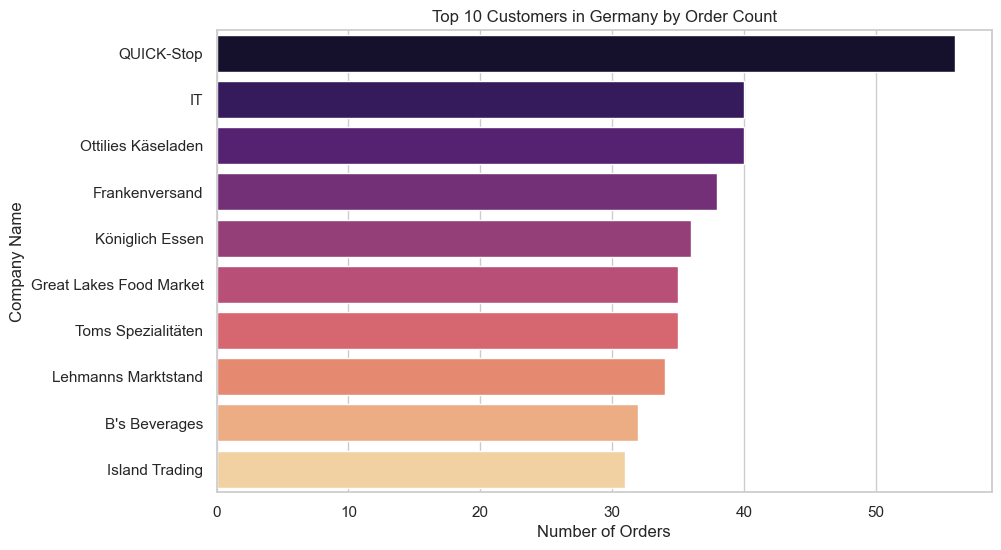

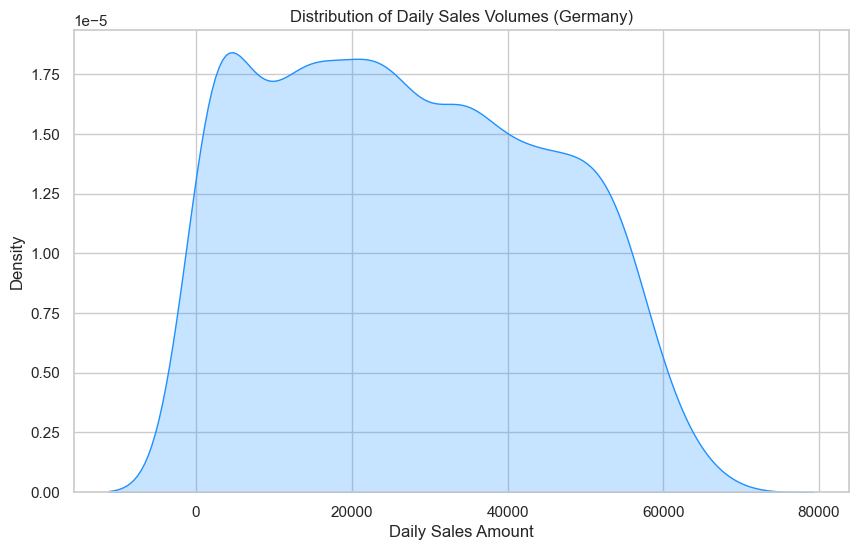

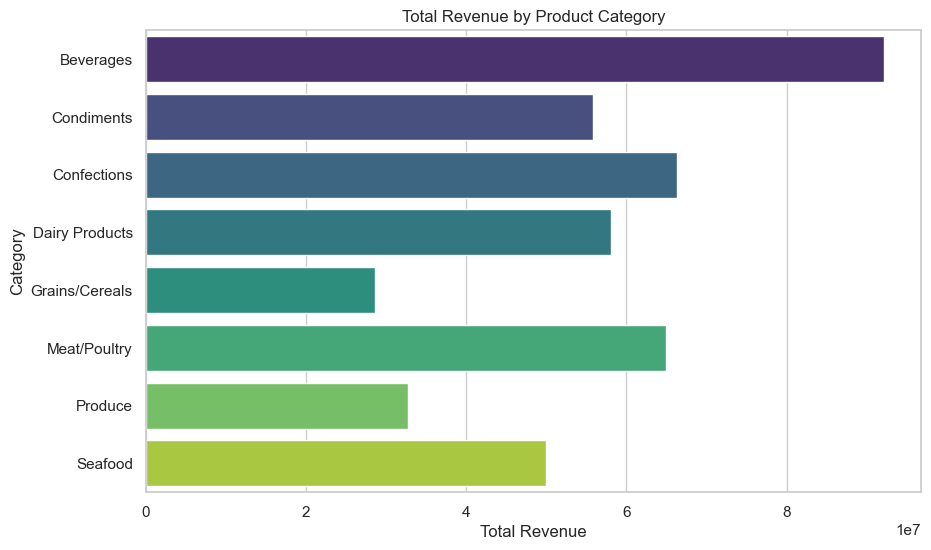

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) Bar plot: Orders per customer (Top 10 in Germany)
plt.figure(figsize=(10, 6))
top_10_germany = df_germany.groupby('CompanyName')['OrderID'].nunique().nlargest(10)
sns.barplot(x=top_10_germany.values, y=top_10_germany.index, hue=top_10_germany.index, palette="magma", legend=False)
plt.title("Top 10 Customers in Germany by Order Count")
plt.xlabel("Number of Orders")
plt.ylabel("Company Name")
plt.show()

# b) Density Plot (KDE) of daily total sales

df_germany['OrderDate'] = pd.to_datetime(df_germany['OrderDate'], format='mixed')
daily_sales = df_germany.groupby('OrderDate')['LineTotal'].sum()

plt.figure(figsize=(10, 6))
sns.kdeplot(daily_sales, fill=True, color="dodgerblue")
plt.title("Distribution of Daily Sales Volumes (Germany)")
plt.xlabel("Daily Sales Amount")
plt.show()

# c) Total Revenue per Category
query_6c = """
SELECT c.CategoryName, SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
"""
df_category_revenue = pd.read_sql(query_6c, conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_category_revenue, x='TotalRevenue', y='CategoryName', hue='CategoryName', palette="viridis", legend=False)
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.show()

In [10]:
import time

# Retrieve full tables
df_all_products = pd.read_sql("SELECT * FROM Products", conn)
df_all_categories = pd.read_sql("SELECT * FROM Categories", conn)
print("Products head:")
display(df_all_products.head())
print("Categories head:")
display(df_all_categories.head())

# Join in Pandas
df_pd_join = pd.merge(df_all_products, df_all_categories, on='CategoryID')

#  Speed Comparison
# SQL way
start_sql = time.time()
pd.read_sql(query_6c, conn)
sql_time = time.time() - start_sql


start_py = time.time()
df_od = pd.read_sql("SELECT * FROM 'Order Details'", conn)
df_p = pd.read_sql("SELECT * FROM Products", conn)
df_c = pd.read_sql("SELECT * FROM Categories", conn)
df_merged = df_od.merge(df_p, on='ProductID').merge(df_c, on='CategoryID')
# Grouping and summing
df_result = df_merged.groupby('CategoryName').apply(lambda x: (x['UnitPrice_x'] * x['Quantity']).sum(), include_groups=False)
py_time = time.time() - start_py

print(f"SQL execution time: {sql_time:.5f} seconds")
print(f"Python execution time: {py_time:.5f} seconds")
print(f"\nConclusion: {'SQL' if sql_time < py_time else 'Python'} was faster in this test.")

Products head:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories head:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


SQL execution time: 0.74042 seconds
Python execution time: 2.56275 seconds

Conclusion: SQL was faster in this test.


In [11]:
# Setup the data
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]})

# a) Wide to Long
print("Original Wide Data:")
display(wide_data)
melted_data = pd.melt(wide_data, id_vars=['store'], var_name='Quarter', value_name='Sales')
print("After pd.melt():")
display(melted_data)

# b) Long to Wide
print("\nOriginal Long Data:")
display(long_data)
pivoted_data = long_data.pivot(index='month', columns='product', values='units_sold')
print("After .pivot():")
display(pivoted_data)

# c) Back to Original
back_to_wide = melted_data.pivot(index='store', columns='Quarter', values='Sales').reset_index()
back_to_wide.columns.name = None # Clean up index name
print("\nVerification - Back to Wide:")
display(back_to_wide)

back_to_long = pivoted_data.reset_index().melt(id_vars='month', value_name='units_sold')
print("Verification - Back to Long:")
display(back_to_long)

Original Wide Data:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After pd.melt():


,store,Quarter,Sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000



Original Long Data:


...

product,Laptop,Phone
month,,
Feb,50,110
Jan,45,120
Mar,55,130



Verification - Back to Wide:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Verification - Back to Long:


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
